In [2]:
pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 2.4 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.3 MB 2.8 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.3 MB 3.1 MB/s eta 0:00:02
   ------------- -------------------------- 2.9/8.3 MB 3.1 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.3 MB 3.2 MB/s eta 0:00:02
   ------------------ --------------------- 3.9/8.3 MB 2.8 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.3 MB 2.7 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 2.7 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.3 M


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Columns: Index(['Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale',
       'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens',
       'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall',
       'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School',
       '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter',
       'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine',
       'Gasconnection', 'AC', 'Wifi', 'Children'splayarea', 'LiftAvailable',
       'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV',
       'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator'],
      dtype='str')


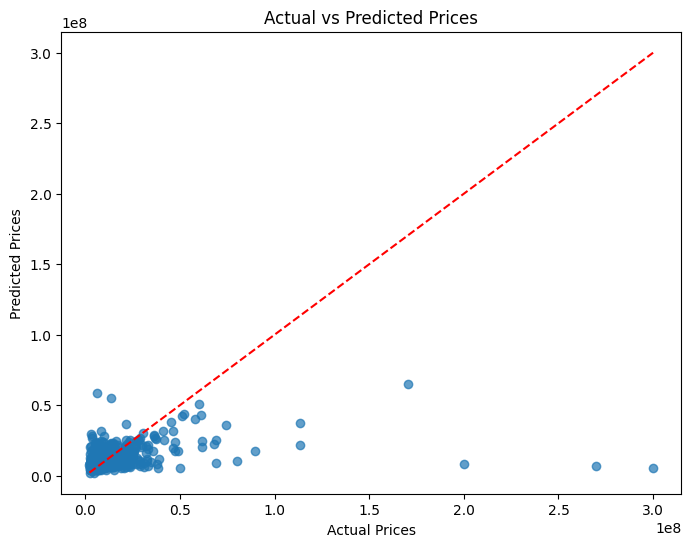

MAE: 5236146.306638807
RMSE: 15252680.750967357


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('house_prices.csv')

print("Columns:", df.columns)

X = df[['Area', 'No. of Bedrooms']].copy()
y = df['Price']

X = X.fillna(X.mean(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))